In [1]:
path_to_add = os.path.abspath('../')
sys.path.append(path_to_add)
from func_curvefit import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
s=24 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [3]:
x = np.arange(0,1.01,.01)

In [4]:
def return_bias(bias_xmin,bias_xmax):
    return bias_xmin/(bias_xmin + bias_xmax)

In [5]:
results_loc = '../../results/schematics/curvefitting'

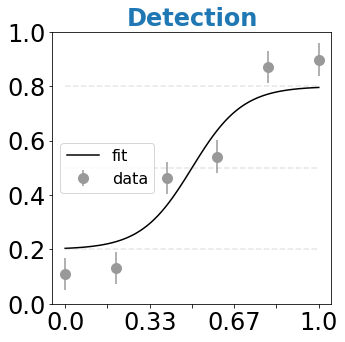

In [79]:
fig, ax = plt.subplots(figsize=(5,5),nrows=1,ncols=1)

bias_xmin = .2
bias_xmax = .2
bias = return_bias(bias_xmin,bias_xmax)

amplitude = 1-bias_xmin-bias_xmax
sigma = .1
center = .5
ypred = bias_xmin + amplitude * sigmoid(x, sigma, center)
ax.plot(x,ypred, color = 'k', label = 'fit')

inds = [0,20,40,60,80,100] # pick 6 evenly spaced events
x_fakedata = x[inds]

# Generate the noise
noise_signs = np.array([1, 1, 1, -1, -1, -1])
np.random.shuffle(noise_signs)
noise_magnitude = np.random.uniform(0, 0.2, len(inds))

# Apply the noise to the selected data points
# y_fakedata = ypred[inds] + noise_signs * noise_magnitude
y_fakedata = [ypred[inds] + noise_signs * np.random.uniform(0, 0.2, len(inds)) for i in range(100)]
y_fakedata = np.array(y_fakedata)

# Calculate mean and standard deviation across rows for each column
y_mean = np.mean(y_fakedata, axis=0)
y_std = np.std(y_fakedata, axis=0)

# ax.plot(x_fakedata,y_fakedata, color = 'orange',marker = 'o',markersize=12,ls='None', label = 'Observed data')
ax.errorbar(x_fakedata, y_mean, yerr=y_std, color = [.6,.6,.6], marker = 'o',markersize=10,ls='None', label = 'data')

ax.set_xlabel('')
ax.set_ylabel('')
# ax.set_xlabel('Directness (objective)')
# ax.set_ylabel('Rating (subjective)')
# ax.set_title('Curve-fitting', fontweight='bold', fontsize = 18,)
ax.set_title('Detection', fontweight='bold', color = 'tab:blue')

ax.set_ylim(0,1)

plt.hlines(bias_xmin,0,1,color = 'grey',alpha = .2, ls = '--')
plt.hlines(1-bias_xmax,0,1,color = 'grey',alpha = .2, ls = '--')
plt.hlines(.5,0,1,color = 'grey',alpha = .2, ls = '--')
ax.set_xticks(np.linspace(0,1,7))
ax.set_xticklabels([str(np.round(i,2)) if ind in [0,2,4,6] else ' ' for ind, i in enumerate(np.linspace(0,1,7))])


ax.legend(loc='center left',fontsize=16) # lower right

plt.savefig(f'{results_loc}/plain_schematic.png',dpi=300, bbox_inches='tight')

In [6]:
s=20 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

# purple: cmyk = 75 100 0 0, rgb [95,0,160], hex: #5F00A0.
# green: cmyk green, rgb [0,166,81], hex: #00A651.
# orange: cmyk 0 50 100 0, rgb [255,128,0], hex: #00A651.

In [7]:
range_color = '#FF8000' # [255,128,0] # orange
bias_color =  '#5F00A0' #[95,0,160] # purple
PSE_color =  '#00A651' #[0,166,81] # green

# Bias

In [34]:
colors_all = ['k','k','k'] #[[.8,.8,.8],[0,0,0],[.6,.6,.6]]
ls_all =  [':','-',(0, (5, 10))]  #[':','-','--'] #[':','-',(0, (5, 10))] #[':','-','-.'] #

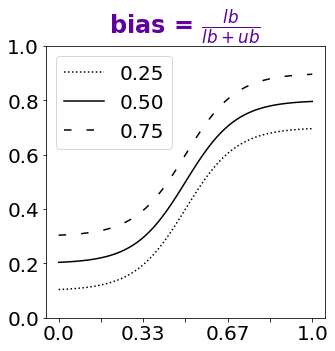

In [35]:
fig, ax = plt.subplots(figsize=(5,5),nrows=1,ncols=1)

# bias_xmin_all = [[0.01,.1,.2], [.2,.2,.2], [0.01,.1,.2], [0.01,.1,.2]]
bias_xmin_all = [.1,.2,.3]
# bias_xmax_all = [[.2,.2,.2], [0.01,.1,.2], [0.01,.1,.2], [.2,.1,0.01,]]
bias_xmax_all = [.3,.2,.1]
# legend_pos = ['upper left','upper left','upper left','upper left']
legend_pos = 'upper left'
# title = ['lb varies','ub varies','lb and ub vary (lb=ub)', r'$\mathbf{lb\; and\;  ub\;  vary\;  (lb\neq ub)}$']#'lb and ub (lb != ub)']
# title = r'$\mathbf{lb\; and\;  ub\;  vary\;  (lb\neq ub)}$'#'lb and ub (lb != ub)'
title = 'Bias levels'
# for i in range(4):

# ax = axs[i]
bias_xmin = bias_xmin_all[0]# y-value at lowest x
bias_xmax = bias_xmax_all[0]# y-value at highest x
amplitude = 1-bias_xmin-bias_xmax
bias = return_bias(bias_xmin,bias_xmax)
sigma = .1
center = .5
ypred = bias_xmin + amplitude * sigmoid(x, sigma, center)
ax.plot(x,ypred, color = colors_all[0], label = f'{bias:.2f}',ls=ls_all[0])

bias_xmin = bias_xmin_all[1]# y-value at lowest x
bias_xmax = bias_xmax_all[1]# y-value at highest x
bias = return_bias(bias_xmin,bias_xmax)
amplitude = 1-bias_xmin-bias_xmax
sigma = .1
center = .5
ypred = bias_xmin + amplitude * sigmoid(x, sigma, center)
ax.plot(x,ypred, color = colors_all[1], label = f'{bias:.2f}',ls=ls_all[1])

bias_xmin = bias_xmin_all[2]# y-value at lowest x
bias_xmax = bias_xmax_all[2] # y-value at highest x
amplitude = 1-bias_xmin-bias_xmax
bias = return_bias(bias_xmin,bias_xmax)
sigma = .1
center = .5
ypred = bias_xmin + amplitude * sigmoid(x, sigma, center)
ax.plot(x,ypred, color = colors_all[2], label = f'{bias:.2f}',ls=ls_all[2])
ax.set_ylim(0,1)

ax.set_title(r'bias = $\frac{lb}{lb + ub}$', fontweight='bold', fontsize=24, color = bias_color)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks(np.linspace(0,1,7))
ax.set_xticklabels([str(np.round(i,2)) if ind in [0,2,4,6] else ' ' for ind, i in enumerate(np.linspace(0,1,7))])

legend =     ax.legend() # title='bias'
# Customize legend text colors
for i in range(3):
    legend.get_texts()[i].set_color(colors_all[i])

plt.savefig(f'{results_loc}/bias_schematic_1option.png',dpi=300, bbox_inches='tight')

# range

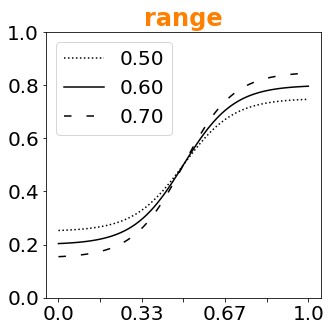

In [36]:
fig, ax = plt.subplots(figsize=(5,5),nrows=1,ncols=1)

bias_xmin_all = [.25,.2,.15]
bias_xmax_all = [.25,.2,.15]

for i in range(3):

    bias_xmin = bias_xmin_all[i]
    bias_xmax = bias_xmin_all[i]
    bias = return_bias(bias_xmin,bias_xmax)

    amplitude = 1-bias_xmin-bias_xmax
    
    sigma = .1
    center = .5
    ypred = bias_xmin + amplitude * sigmoid(x, sigma, center)
    ax.plot(x,ypred, color = colors_all[i], label = f'{amplitude:.2f}',ls=ls_all[i])


    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('range', fontweight='bold', fontsize = 24, color = range_color)

ax.set_xticks(np.linspace(0,1,7))
ax.set_xticklabels([str(np.round(i,2)) if ind in [0,2,4,6] else ' ' for ind, i in enumerate(np.linspace(0,1,7))])

legend =     ax.legend()#title='range')
# Customize legend text colors
for i in range(3):
    legend.get_texts()[i].set_color(colors_all[i])

plt.ylim(0,1)
plt.tight_layout()

plt.savefig(f'{results_loc}/amplitude_schematic.png',dpi=300, bbox_inches='tight')

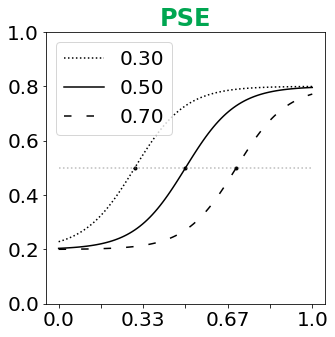

In [37]:
fig, ax = plt.subplots(figsize=(5,5),nrows=1,ncols=1)

bias_xmin = .2
bias_xmax = .2
bias = return_bias(bias_xmin,bias_xmax)
amplitude = 1-bias_xmin-bias_xmax

center_all = [.3,.5,.7]

for i in range(3):

    sigma = .1
    center = center_all[i]#.5
    ypred = bias_xmin + amplitude * sigmoid(x, sigma, center)
    xpred = x[np.argmin(np.abs(ypred-.5))]
    plt.hlines(.5,0,1,color = 'grey',alpha = .2, ls = ':')
    ax.plot(x,ypred, color = colors_all[i], label = f'{xpred:.2f}',ls=ls_all[i])

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('PSE', fontsize = 24, fontweight='bold', color = PSE_color)
    ax.set_ylim(0,1)

ax.scatter([0.3],[0.5],marker = '.', color = colors_all[0])
ax.scatter([0.5],[0.5],marker = '.', color = colors_all[1])
ax.scatter([0.7],[0.5],marker = '.', color = colors_all[2])

ax.set_xticks(np.linspace(0,1,7))
ax.set_xticklabels([str(np.round(i,2)) if ind in [0,2,4,6] else ' ' for ind, i in enumerate(np.linspace(0,1,7))])

legend = ax.legend(loc = 'upper left')#,title = 'PSE')
# Customize legend text colors
for i in range(3):
    legend.get_texts()[i].set_color(colors_all[i])

plt.savefig(f'{results_loc}/obj_center_schematic.png',dpi=300, bbox_inches='tight')
